In [ ]:
!pip install ultralytics==8.2.103
!pip install opencv-python-headless==4.10.0.84
!pip install matplotlib==3.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 46.2 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
!rm -rf Deteccion-de-Objetos-YOLO-con-Python
!git clone https://github.com/Dani-CarSo/Detector-de-objetos

Cloning into 'Detector-de-objetos'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 4), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 9.52 KiB | 2.38 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
import os

directorio_objetivo = 'Detector-de-objetos'

if os.path.basename(os.getcwd()) != directorio_objetivo:
    try:
        os.chdir(directorio_objetivo)
        print(f"Directorio cambiado a: {os.getcwd()}")
    except FileNotFoundError:
        print(f"Error: No se encontró el directorio '{directorio_objetivo}'. Asegúrate de que el repositorio esté clonado.")

if os.path.basename(os.getcwd()) == directorio_objetivo:
    print(f"Ya estás en el directorio: {os.getcwd()}")
else:
    print("Hubo un problema cambiando de directorio.")

Directorio cambiado a: /content/Detector-de-objetos
Ya estás en el directorio: /content/Detector-de-objetos


In [4]:
import sys
sys.path.append('/content/Detector-de-objetos')
from yolo_modelo import get_model, get_dataset_config, train, evaluate, save_model, get_best_weights_path

import os
os.environ["WANDB_MODE"] = "disabled"

data_yaml = get_dataset_config("/content/Detector-de-objetos/coco128.yaml")
net = get_model("yolov8n.pt")

train(net, data_yaml, epochs=3, imgsz=640, batch=16, device='cpu')
evaluate(net)

pesos_finales = get_best_weights_path(net)
save_model(pesos_finales, "mejor_modelo_yolo.pt")

 Usando configuración de dataset: /content/Detector-de-objetos/coco128.yaml
 Cargando modelo base: yolov8n.pt
 Entrenando modelo
   epochs : 3
   imgsz  : 640
   batch  : 16
   device : cpu

New https://pypi.org/project/ultralytics/8.4.72 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Detector-de-objetos/coco128.yaml, epochs=3, time=None, patience=20, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=runs/detect, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7,

train: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1837: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]

Plotting labels to runs/detect/train4/labels.jpg... 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:33<00:00,  8.44s/it]


                   all        128        929      0.703      0.528      0.641      0.477
                person         61        254      0.853      0.642      0.771      0.542
               bicycle          3          6      0.666      0.333      0.322      0.279
                   car         12         46      0.915      0.217      0.279      0.176
            motorcycle          4          5      0.669      0.808      0.938      0.742
              airplane          5          6      0.831      0.821      0.903      0.709
                   bus          5          7      0.747      0.714      0.737      0.663
                 train          3          3      0.571      0.667      0.806      0.731
                 truck          5         12          1      0.326       0.52      0.333
                  boat          2          6      0.304      0.167      0.406      0.251
         traffic light          4         14      0.727      0.195      0.201      0.138
             stop sig

val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:29<00:00,  3.65s/it]


                   all        128        929      0.669      0.556      0.633      0.471
                person         61        254      0.815      0.674      0.772      0.545
               bicycle          3          6      0.512      0.333       0.32      0.278
                   car         12         46      0.791      0.217      0.279      0.176
            motorcycle          4          5      0.679      0.854      0.898      0.718
              airplane          5          6      0.801      0.833      0.903      0.709
                   bus          5          7      0.621      0.714      0.736      0.662
                 train          3          3       0.55      0.667      0.806      0.731
                 truck          5         12          1      0.417      0.494      0.304
                  boat          2          6      0.232      0.167      0.361      0.172
         traffic light          4         14      0.738      0.204      0.205       0.14
             stop sig

'mejor_modelo_yolo.pt'

In [6]:
import sys
sys.path.append('/content/Detector-de-objetos')
from yolo_modelo import load_model, evaluate

loaded_net = load_model("mejor_modelo_yolo.pt")
evaluate(loaded_net, data_yaml="/content/Detector-de-objetos/coco128.yaml")

 Cargando modelo desde: mejor_modelo_yolo.pt
 Evaluando modelo...
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:29<00:00,  3.74s/it]


                   all        128        929      0.669      0.556      0.633      0.471
                person         61        254      0.815      0.674      0.772      0.545
               bicycle          3          6      0.512      0.333       0.32      0.278
                   car         12         46      0.791      0.217      0.279      0.176
            motorcycle          4          5      0.679      0.854      0.898      0.718
              airplane          5          6      0.801      0.833      0.903      0.709
                   bus          5          7      0.621      0.714      0.736      0.662
                 train          3          3       0.55      0.667      0.806      0.731
                 truck          5         12          1      0.417      0.494      0.304
                  boat          2          6      0.232      0.167      0.361      0.172
         traffic light          4         14      0.738      0.204      0.205       0.14
             stop sig

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x787649856b70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,

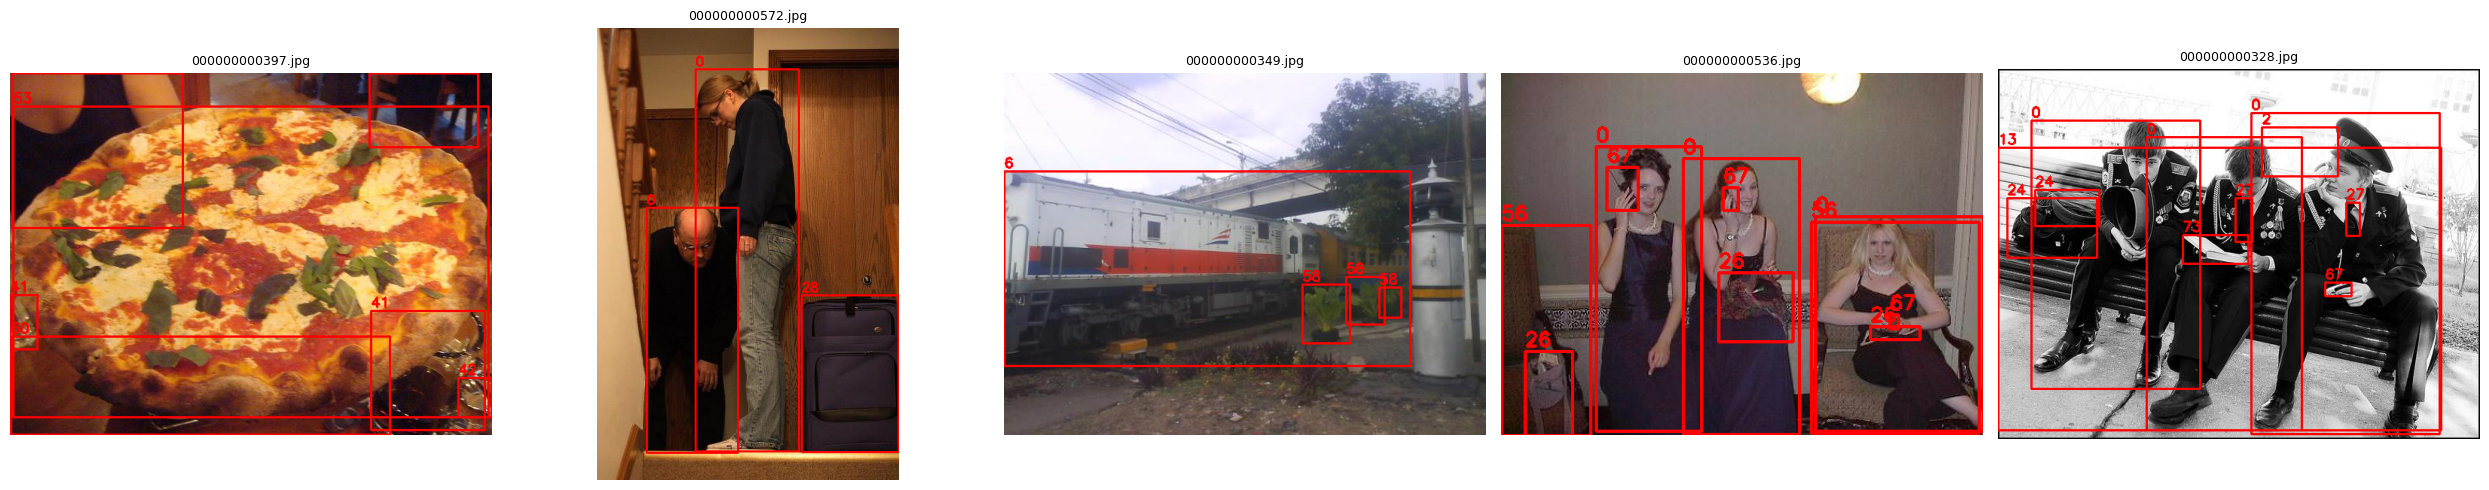

In [8]:
import sys
sys.path.append('/content/Detector-de-objetos')
from yolo_visualizacion import explore_dataset

explore_dataset("/content/datasets/coco128/images/train2017", num_images=5)

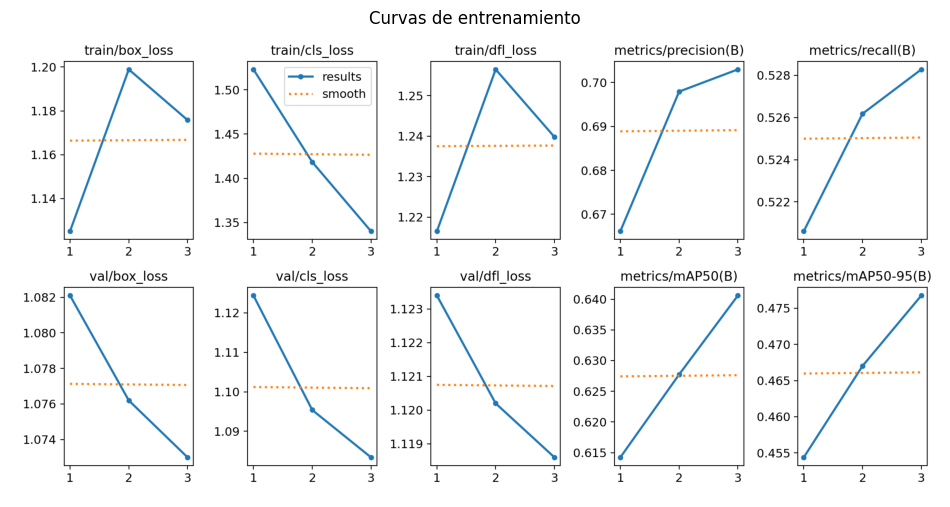

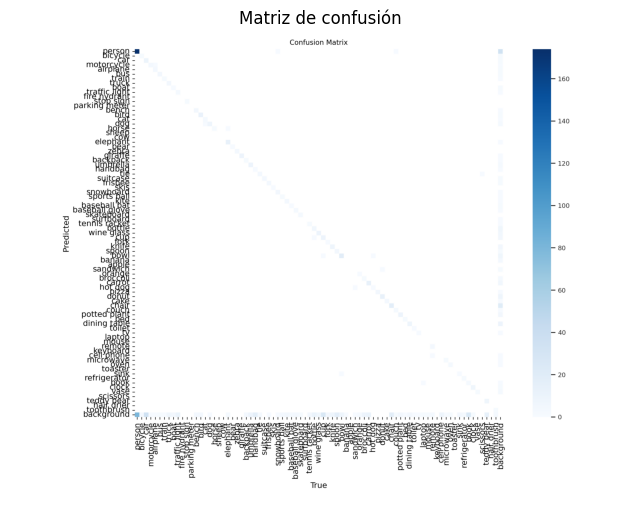

In [9]:
import sys
sys.path.append('/content/Detector-de-objetos')
from yolo_visualizacion import show_training_curves, show_confusion_matrix

carpeta_resultados = net.trainer.save_dir
show_training_curves(carpeta_resultados)
show_confusion_matrix(carpeta_resultados)

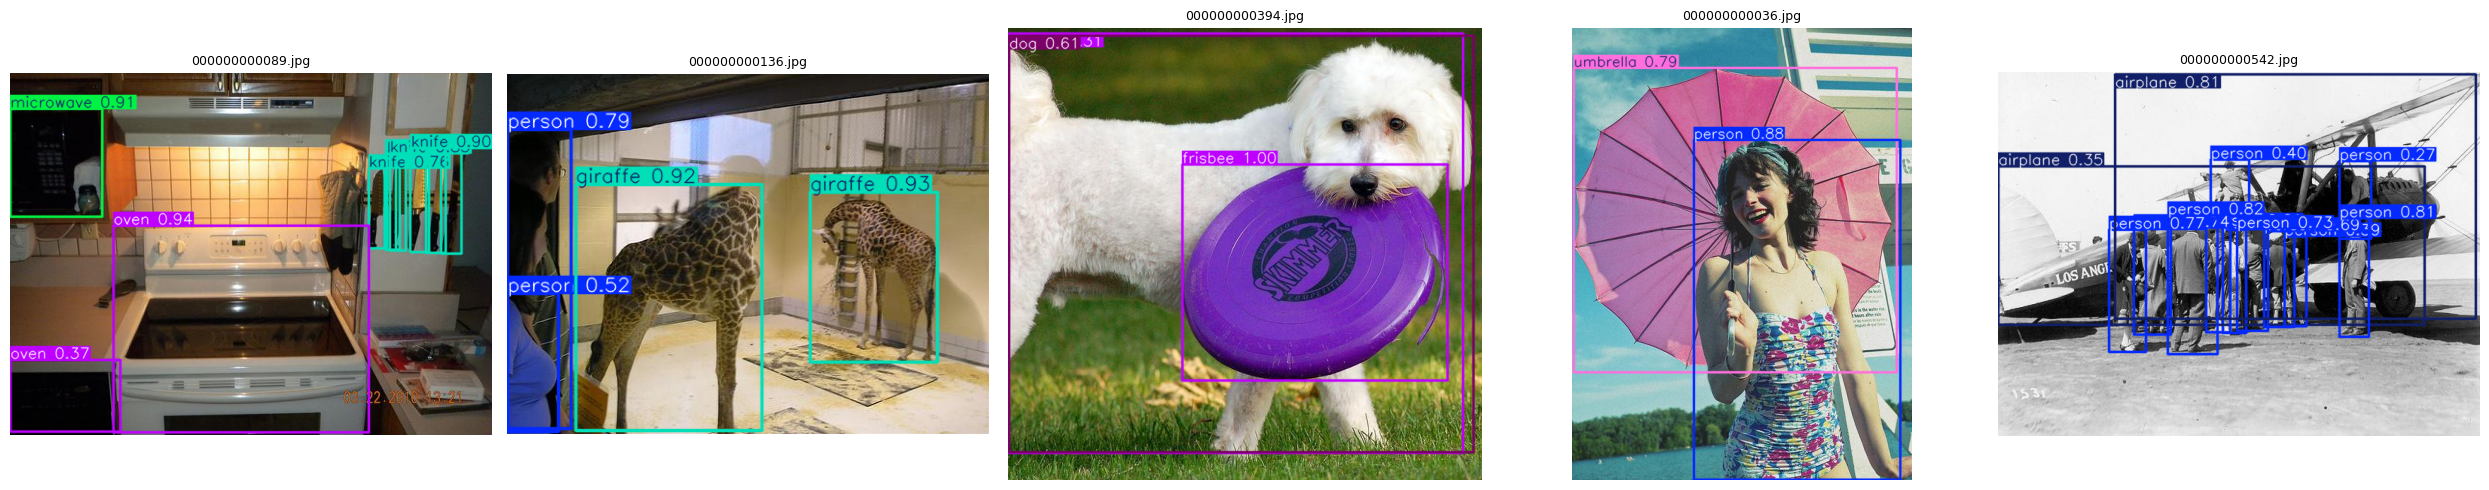

In [10]:
import sys
sys.path.append('/content/Detector-de-objetos')
from yolo_visualizacion import show_predictions

show_predictions(loaded_net, "/content/datasets/coco128/images/train2017", num_images=5)